In [2]:
from pathlib import Path
from ocularrigidity.data.measurements.pulsation_results import load_pulsation_results

ROOT_CARDIAC = Path("/media/clement/HD/Santiago/OcularRigidity/FullPipeline/")


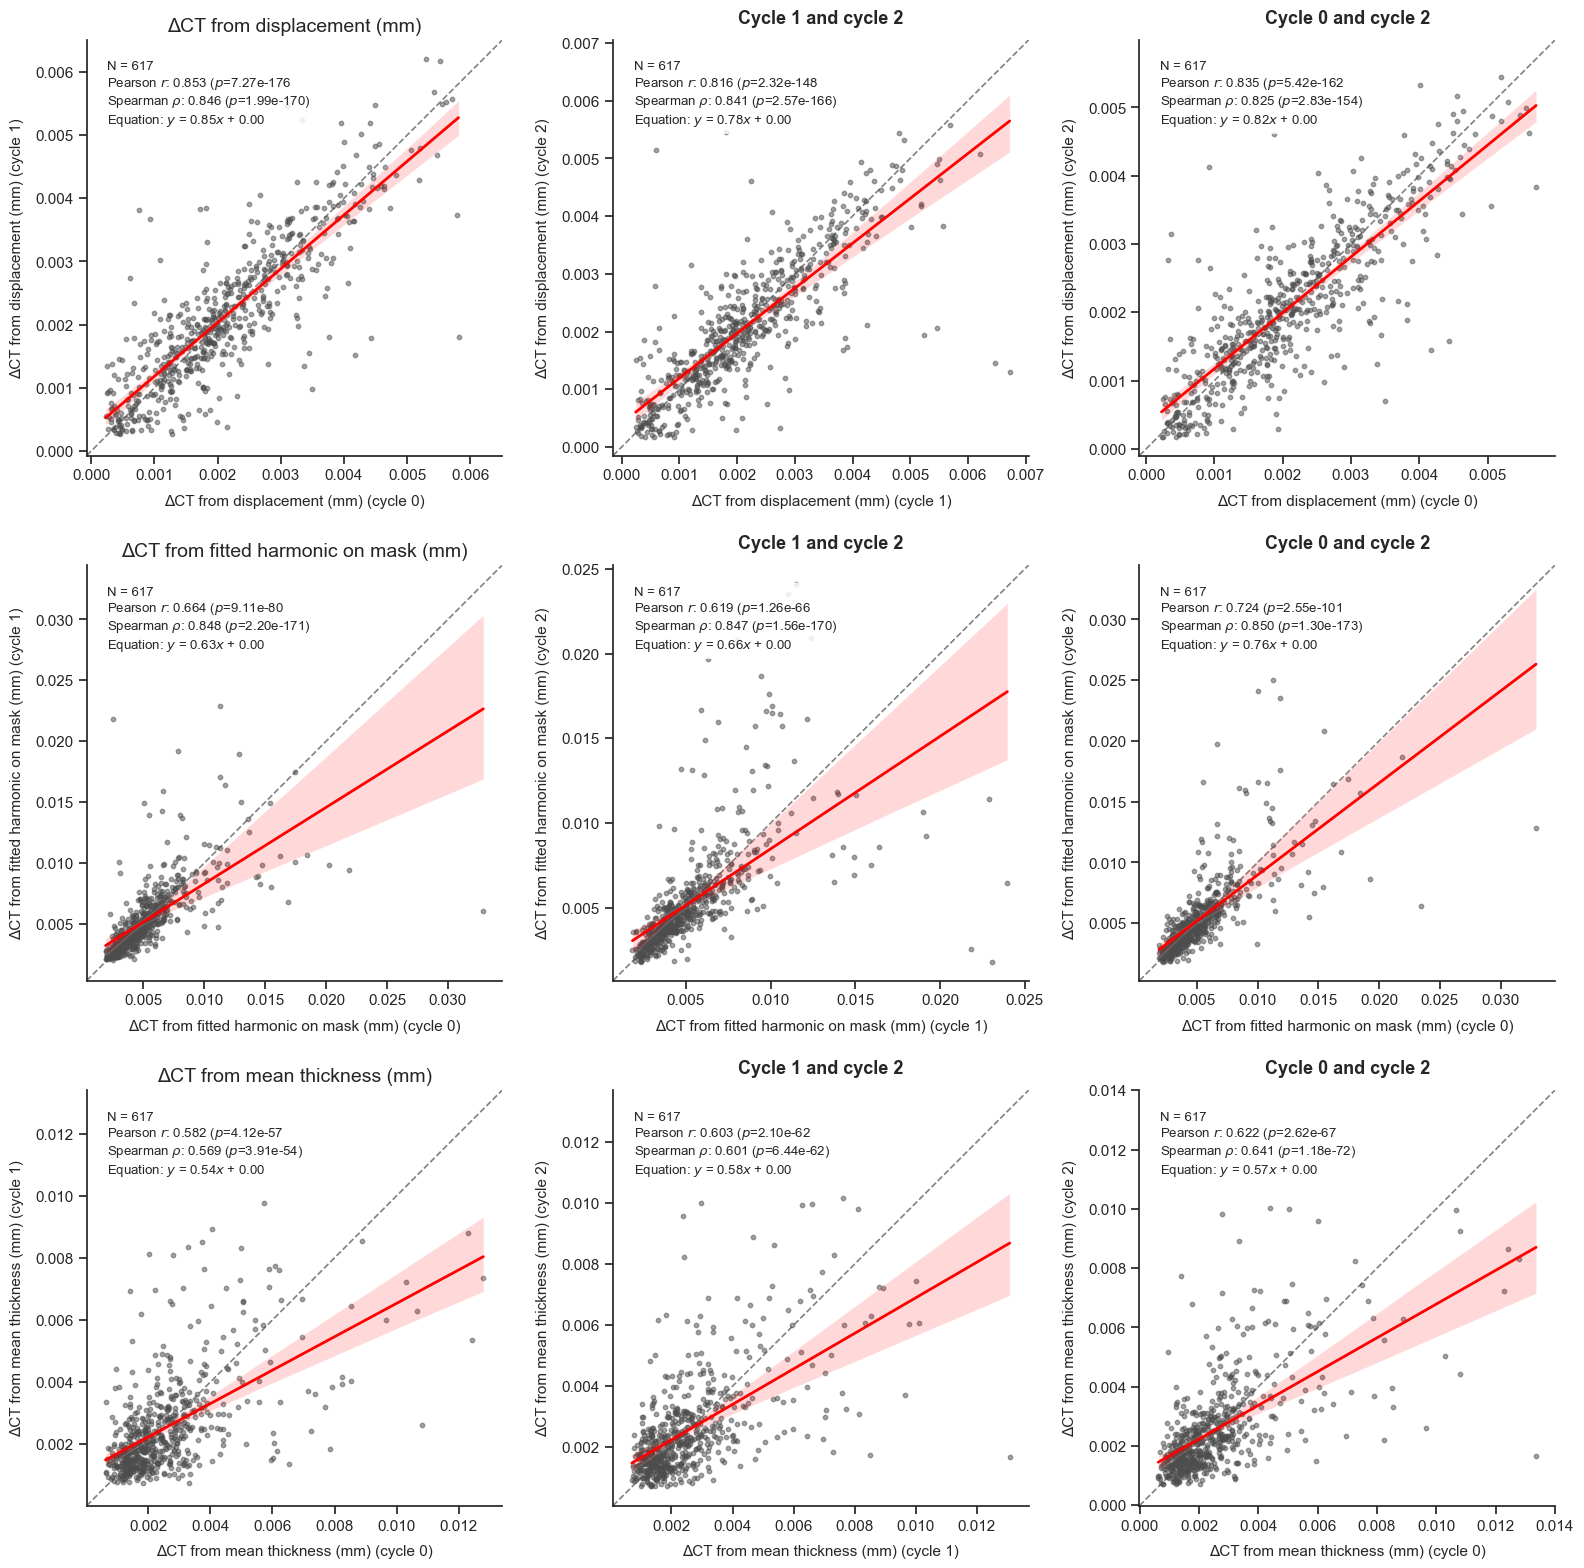

In [35]:
# | label: fig-cycles-comparison
# | echo: false
# | warning: false

import seaborn as sns
import matplotlib.pyplot as plt

from ocularrigidity.data.measurements.cohort import build_cohort
from ocularrigidity.stats.plot import regression_plot_with_stats

cases, cycles = load_pulsation_results(ROOT_CARDIAC, overwrite=False)
df = build_cohort(ROOT_CARDIAC, overwrite=False)
variables = [
    ("deltaCT", "ΔCT from displacement (mm)"),
    ("deltaCT_Mask", "ΔCT from fitted harmonic on mask (mm)"),
    ("deltaCT_MaskThickness", "ΔCT from mean thickness (mm)"),
]
comparisons_cycles = [(0, 1), (1, 2), (0, 2)]
fig, axes = plt.subplots(
    nrows=len(variables), ncols=len(comparisons_cycles), figsize=(16, 16)
)
for i, (var, label) in enumerate(variables):
    for j, (c1, c2) in enumerate(comparisons_cycles):
        ax = axes[i, j]
        cases_x = cycles[cycles.cycle == c1]
        cases_y = cycles[cycles.cycle == c2]
        # Merge the two dataframes on the "Case" column to ensure we only compare cases that exist in both cycles
        cases_x = cases_x.set_index("video")
        cases_y = cases_y.set_index("video")
        merged = cases_x.join(
            cases_y, lsuffix=f"_cycle{c1}", rsuffix=f"_cycle{c2}", how="inner"
        )
        regression_plot_with_stats(
            merged,
            x=f"{var}_cycle{c1}",
            y=f"{var}_cycle{c2}",
            ax=ax,
            xlabel=f"{label} (cycle {c1})",
            ylabel=f"{label} (cycle {c2})",
            title=f"Cycle {c1} and cycle {c2}",
            drop_outlier_quantile=0.99,
            print_stats=False,
        )
        # Put a title for the row
        if j == 0:
            ax.set_title(f"{label}", fontsize=14)
plt.tight_layout()
plt.show()


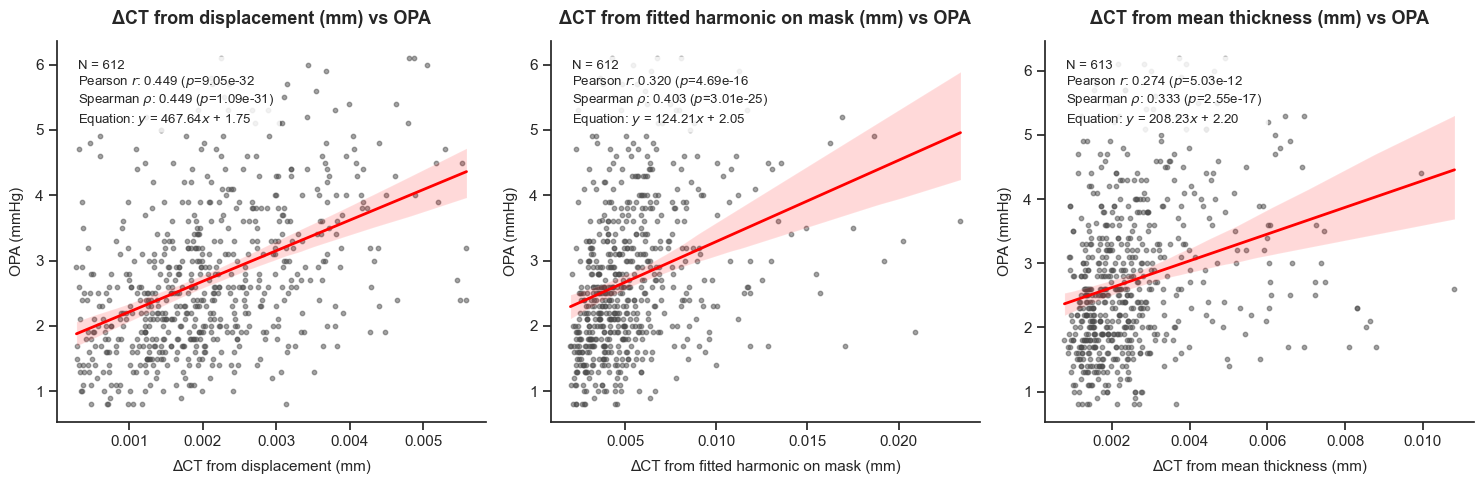

In [34]:
# | label: fig-OPA-VS-dCT
# | echo: false
# | warning: false
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df["deltaCT+CT"] = df["deltaCT"] + df["minCT"]
for i, (var, label) in enumerate(variables):
    ax = axes[i]
    regression_plot_with_stats(
        df,
        x=var,
        y="OPA",
        ax=ax,
        xlabel=label,
        ylabel="OPA (mmHg)",
        title=f"{label} vs OPA",
        drop_outlier_quantile=0.99,
        print_stats=False,
        equal_axis=False,
    )
plt.show()